In [1]:
## Libraries needs to run the script ##
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import ScalarFormatter
from pylab import rc
from pathlib import Path

In [2]:
## read data files using pandas ##
data = pd.read_csv("LIG-LIG-LJ-final.dat",names=["Conc", "IE"], sep=r'\s+', skiprows=1)
data1 = pd.read_csv("LIG-IL-LJ-final.dat",names=["Conc", "IE"], sep=r'\s+', skiprows=1)

In [5]:
## read the LJ and coul IE for IL-IL(40per) ##
df_LJ = pd.read_csv("data_LJ.txt", names=["values"])
df_coul = pd.read_csv("data_coul.txt", names=["values"])
df_sum_40 = df_coul["values"]+df_LJ["values"]

In [7]:
## read the LJ and coul IE for IL-IL(20per) ##
df1_LJ = pd.read_csv("../../../new-test/interaction-energy/data_LJ.txt", names=["values"])
df1_coul = pd.read_csv("../../../new-test/interaction-energy/data_coul.txt", names=["values"])
df1_sum_20 = df1_coul["values"]+df1_LJ["values"]

In [9]:
# Step 1: Wrap the Series as DataFrames if they aren't already
df1_sum_20 = pd.DataFrame({'Pluronic': '20', 'Total_IE': df1_sum_20})
df_sum_40  = pd.DataFrame({'Pluronic': '40', 'Total_IE': df_sum_40})

# Step 2: Concatenate with proper labeling
final_plot_data = pd.concat([df1_sum_20, df_sum_40], ignore_index=True)

print(final_plot_data)

  Pluronic       Total_IE
0       20 -460795.037175
1       40 -307276.928320


In [11]:
final_plot_data.to_csv("IL-IL-tot.csv", index=True)
data2 = pd.read_csv("IL-IL-tot.csv")

In [13]:
data2

,Unnamed: 0,Pluronic,Total_IE
0,0,20,-460795.037175
1,1,40,-307276.928320


In [17]:
##final_plot_data = pd.concat([df1_sum_20,df_sum_40], ignore_index=True)

In [19]:
##final_plot_data

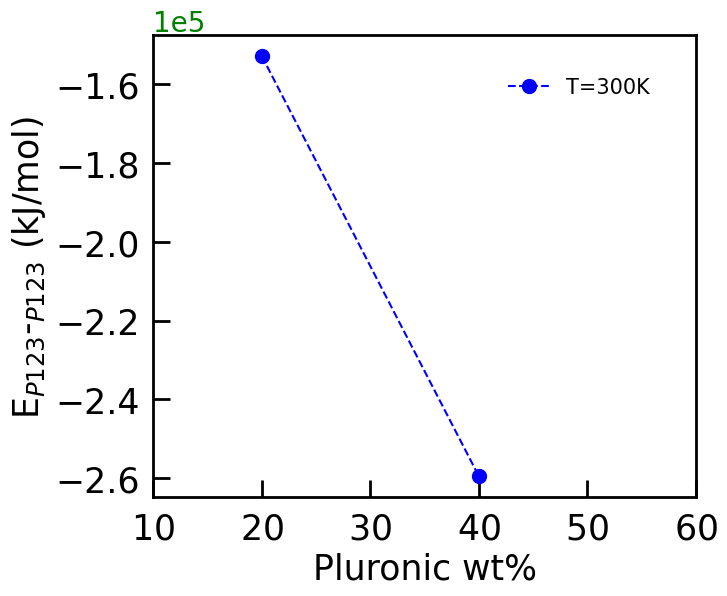

In [21]:
## final plot of IE CG & AA data ##
fig = plt.figure(1034, figsize=(7,6))
ax = fig.add_subplot(111)
from pylab import*
rc('axes', linewidth=2.0)

plt.plot(data1["Conc"], data1['IE'], color='b',  marker='o', linestyle='--', linewidth=1.5, label="T=300K", markersize=10)

plt.ylabel(r'E$_{P123}$-$_{P123}$ (kJ/mol)', fontsize=25, labelpad=5,  fontname='DejaVu Sans')
plt.xlabel('Pluronic wt%',fontsize=25,labelpad=5, fontname='DejaVu Sans' )
#plt.ylim([-500000.01, -300000.05])
#plt.yticks(np.arange(-360000.01, -60000.05,  40000), fontsize=25, fontname='DejaVu Sans')
#plt.xlim([10.0, 60.01])
plt.xticks(np.arange(10.0, 60.01, 10), fontsize=25, fontname='DejaVu Sans')
plt.legend(fontsize=15, bbox_to_anchor=(0.95,0.95), loc='upper right', edgecolor='white')
#ax2=ax1.twinx()

plt.tick_params(axis='both', which='major', length=12, direction='in', width=2, labelsize=25, pad=10)
ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(5,5))

## Customize the offset text ##
offset_text = ax.yaxis.get_offset_text()
offset_text.set_size(20)  # Set font size
offset_text.set_color('green')  # Optional: change color
#plt.title("Self aggregation for Pluronic", fontsize=16, color='black', loc='center', fontname='serif')
plt.savefig('test-1.png', bbox_inches='tight', dpi=600)

# Displaying the IE plot

plt.show()

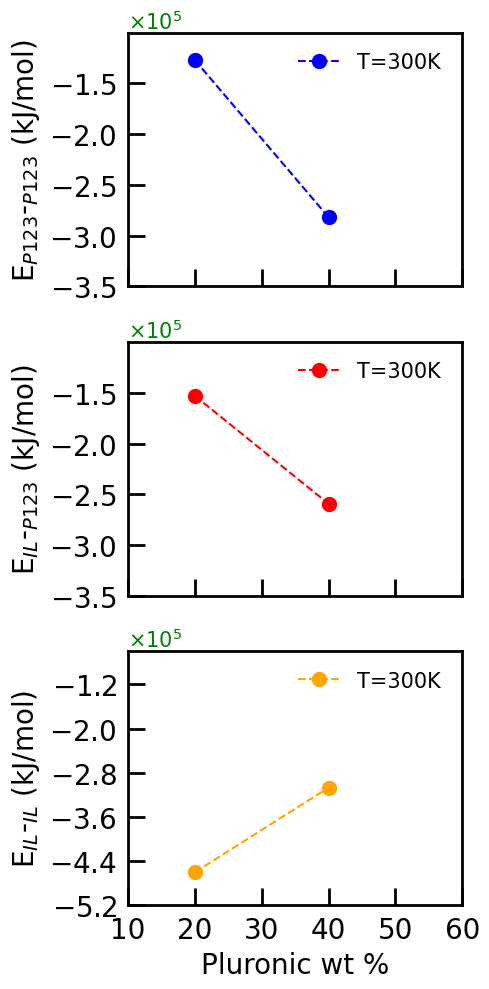

In [17]:
# Set global axis line width
from pylab import*
rc('axes', linewidth=2.0)

# Create subplots: 1 row, 2 columns
fig, axs = plt.subplots(3, 1, figsize=(5, 10), sharex=True)

# First plot
axs[0].plot(data["Conc"],data["IE"],color='b',  marker='o', linestyle='--', linewidth=1.5, label="T=300K", markersize=10)
axs[0].set_xlim([10.01, 60.01])
axs[0].set_ylim([-350000.01, -100000.05])
axs[0].set_yticks(np.arange(-350000.01, -100000.05, 50000))
#axs[0].set_title('A', fontsize=18, fontname='serif', loc='left')
axs[0].legend(fontsize=15, bbox_to_anchor=(0.99, 0.998), loc='upper right', edgecolor='white')
axs[0].set_ylabel(r'E$_{P123}$-$_{P123}$ (kJ/mol)', fontsize=20, fontname='DejaVu Sans', labelpad=5)
##axs[0].set_xlabel('Pluronic wt %', fontsize=20, fontname='DejaVu Sans', labelpad=5)

# Second plot
axs[1].plot(data1["Conc"],data1["IE"],color='r',  marker='o', linestyle='--', linewidth=1.5, label="T=300K", markersize=10)

axs[1].set_xlim([10.01, 60.01])
axs[1].set_ylim([-350000.01, -100000.05])
axs[1].set_yticks(np.arange(-350000.01, -100000.05, 50000))
#axs[0].set_title('A', fontsize=18, fontname='DejaVu Sans', loc='left')
axs[1].legend(fontsize=15, bbox_to_anchor=(0.99, 0.998), loc='upper right', edgecolor='white')
axs[1].set_ylabel(r'E$_{IL}$-$_{P123}$ (kJ/mol)', fontsize=20, fontname='DejaVu Sans', labelpad=5)
##axs[1].set_xlabel('Pluronic wt %', fontsize=20, fontname='DejaVu Sans', labelpad=5)
# Remove y-ticks from second plot if you want visual separation
#axs[1].tick_params(axis='y', which='both', left=False, labelleft=False)

# Third plot
axs[2].plot(data2["Pluronic"],data2['Total_IE'],color='orange',  marker='o', linestyle='--', linewidth=1.5, label="T=300K", markersize=10)

axs[2].set_xlim([10.01, 60.01])
axs[2].set_ylim([-520000.01, -60000.05])
axs[2].set_yticks(np.arange(-520000.01, -60000.05, 80000))
#axs[0].set_title('A', fontsize=18, fontname='DejaVu Sans', loc='left')
axs[2].legend(fontsize=15, bbox_to_anchor=(0.99, 0.998), loc='upper right', edgecolor='white')
axs[2].set_ylabel(r'E$_{IL}$-$_{IL}$ (kJ/mol)', fontsize=20, fontname='DejaVu Sans', labelpad=5)
axs[2].set_xlabel('Pluronic wt %', fontsize=20, fontname='DejaVu Sans', labelpad=5)
# Remove y-ticks from second plot if you want visual separation
#axs[2].tick_params(axis='y', which='both', left=False, labelleft=False)

# Ticks & fonts
for ax in axs:
    ax.set_xticks(np.arange(10.01, 60.05, 10))
    #ax.set_yticks(np.arange(-520000.01, -60000.05, 80000))
    ax.tick_params(axis='both', which='major', length=12, direction='in', width=2, labelsize=20, pad=8)
    ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style='sci', axis='y', scilimits=(5,5))

## Customize the offset text ##
    offset_text = ax.yaxis.get_offset_text()
    offset_text.set_size(15)  # Set font size
    offset_text.set_color('green')  # Optional: change color

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontname('DejaVu Sans')
# Layout & save
plt.tight_layout()
plt.savefig('three_plots.png', dpi=500,  bbox_inches='tight')
plt.show()     